<a href="https://colab.research.google.com/github/TsotneDzeria/RML/blob/main/Individual_assignment_2_RML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Individual Assignment 2 - Tsotne Dzeria
*DNSC 6330: Responsible Machine Learning*

GenAI Disclosure: Claude AI was used for code review and to improve the clarity and flow of written responses. All ideas, analysis, and conclusions are entirely my own.

# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [49]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading dataset

import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

# Number of rows in dataset
raw_data.shape[0]

7214

In [3]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons to remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
import numpy as np

# Data preprocessing and feature construction

# Defining variable groups
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Selecting relevant columns
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# Applying filtering conditions (same as R workflow)
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Converting datetime variables
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Converting categorical variables
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Creating derived categorical features with same reference groups
df["crime_factor"] = df["c_charge_degree"]

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Greater than 45", "Less than 25"]
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].cat.categories if c != "Caucasian"]
)

df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] == "Low", "LowScore", "HighScore"),
    categories=["LowScore", "HighScore"]
)

# Number of rows after preprocessing
df.shape[0]

6172

In [5]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   category      
 2   race                     6172 non-null   category      
 3   age_cat                  6172 non-null   category      
 4   score_text               6172 non-null   category      
 5   sex                      6172 non-null   category      
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   category      
 10  two_year_recid           6172 non-null   category      
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
# -------------------------------
# Analyze relationship between length of stay and COMPAS score
# -------------------------------

# Ensure datetime conversion is correct
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"], errors="coerce")
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"], errors="coerce")

# Calculate length of stay (in days)
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

# Compute correlation
correlation = df["length_of_stay"].corr(df["decile_score"])
correlation

np.float64(0.20747808478031807)

The correlation between length of stay and decile score is positive, indicating that individuals with higher COMPAS risk scores tend to have slightly longer jail stays. However, the strength of the correlation is relatively weak, suggesting that while there is a relationship, COMPAS scores alone do not strongly determine the length of incarceration.

After filtering we have the following demographic breakdown:

In [8]:
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
df["race"].value_counts().sort_index()

,count
race,
African-American,3175
Asian,31
Caucasian,2103
Hispanic,509
Native American,11
Other,343


In [10]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
df["score_text"].value_counts().sort_index()

,count
score_text,
High,1144
Low,3421
Medium,1607


In [12]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
df["sex"].value_counts().sort_index()

,count
sex,
Female,1175
Male,4997


In [14]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
df[df["two_year_recid"] == 1].shape[0]

2809

In [16]:
df[df["two_year_recid"] == 1].shape[0] / df.shape[0] * 100

45.51198963058976

Approximately 45.5% of individuals in the dataset recidivated within two years. This provides a baseline understanding of the prevalence of reoffending in the filtered sample and is important for evaluating the predictive performance of the COMPAS scores in later analysis.

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

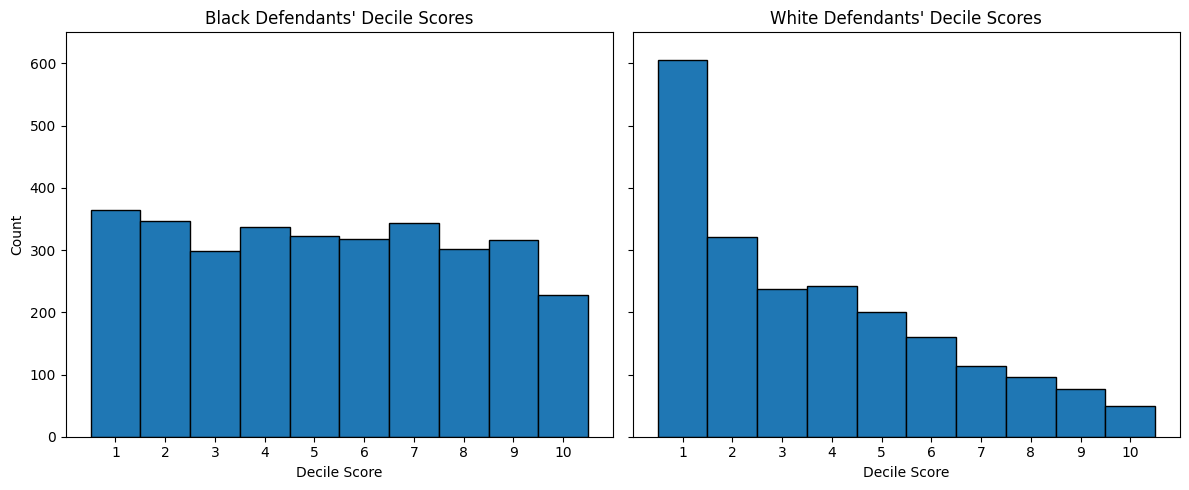

In [17]:
# -------------------------------
# Compare decile score distributions by race
# -------------------------------

import matplotlib.pyplot as plt
import numpy as np

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Black defendants
axes[0].hist(black_df["decile_score"], bins=np.arange(1, 12) - 0.5, edgecolor="black")
axes[0].set_title("Black Defendants' Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(1, 11))
axes[0].set_ylim(0, 650)

# White defendants
axes[1].hist(white_df["decile_score"], bins=np.arange(1, 12) - 0.5, edgecolor="black")
axes[1].set_title("White Defendants' Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_xticks(range(1, 11))
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

The distributions show clear differences in COMPAS decile scores between Black and White defendants. Black defendants appear more frequently in higher decile score categories, while White defendants are more concentrated in lower score ranges. This suggests a potential disparity in how risk scores are assigned across racial groups, which motivates further analysis in the modeling section.

In [18]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [19]:
# -------------------------------
# Logistic regression model (COMPAS score prediction)
# -------------------------------

# Create binary target: 1 = HighScore, 0 = LowScore
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

import statsmodels.formula.api as smf

model_glm = smf.logit(
    "score_binary ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df
).fit()

model_glm.summary()

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        23:24:47   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
===================================================================================================
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5255      0.079    -19.430      0.000      -1.679      -1.372
gender_factor[T.Female]             0.2213      0.080      2.783      0.005       0.065       0.377
age_factor[T.Greater than 45]      -1.3556      0.099    -13.682      0.000      -1.550      -1.161
age_factor[T.Less than 25]          1.3084      0.076     17.232      0.000       1.160       1.457
race_factor[T.African-American]     0.4772      0.069      6.881      0.000       0.341       0.613
race_factor[T.Asian]               -0.2544      0.478     -0.532      0.595      -1.192       0.683
race_factor[T.Hispanic]            -0.4284      0.128     -3.344      0.001      -0.680      -0.177
race_factor[T.Native American]      1.3942      0.766      1.820      0.069      -0.107       2.896
race_factor[T.Other]               -0.8263      0.162     -5.098      0.000      -1.144      -0.509
crime_factor[T.M]                  -0.3112      0.067     -4.677      0.000      -0.442      -0.181
two_year_recid[T.1]                 0.6859      0.064     10.713      0.000       0.560       0.811
priors_count                        0.2689      0.011     24.221      0.000       0.247       0.291
===================================================================================================
"""

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [20]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

np.float64(1.4528408658138932)

Women are 19.4% more likely than men to get a higher score.

In [21]:
np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))

np.float64(1.1947978508506671)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [22]:
np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))

np.float64(2.4961202077189455)

In [23]:
# -------------------------------
# Generate predicted probabilities and classifications
# -------------------------------

# Predicted probabilities
df["pred_prob"] = model_glm.predict(df)

# Convert probabilities into classes (threshold = 0.5)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")
df["pred_class"] = pd.Categorical(df["pred_class"], categories=["No Recid", "Recid"])

In [24]:
# -------------------------------
# Evaluate model performance (confusion matrix and metrics)
# -------------------------------

# Confusion matrix
overall_cm = pd.crosstab(df["pred_class"], df["two_year_recid"])

print("\n── Overall Confusion Matrix ──────────────────────────\n")
print(overall_cm)

# Extract values
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

# Metrics
accuracy = (TP + TN) / n
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────

two_year_recid     0     1
pred_class                
No Recid        2653   945
Recid            710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


The confusion matrix summarizes the model’s predictions compared to actual outcomes. The accuracy measures the overall correctness of the model, while precision indicates how often predicted recidivism is correct. Recall reflects the model’s ability to identify actual recidivists. The false positive rate (FPR) and false negative rate (FNR) provide insight into the types of errors the model makes. These metrics help evaluate not only overall performance but also whether the model may disproportionately misclassify certain groups.

In [25]:
# -------------------------------
# Evaluate model performance by race
# -------------------------------

df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

race_metrics = (
    df.groupby("race")
      .apply(lambda x: pd.Series({
          "n": len(x),
          "TP": ((x["pred"] == 1) & (x["actual"] == 1)).sum(),
          "TN": ((x["pred"] == 0) & (x["actual"] == 0)).sum(),
          "FP": ((x["pred"] == 1) & (x["actual"] == 0)).sum(),
          "FN": ((x["pred"] == 0) & (x["actual"] == 1)).sum()
      }))
      .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False)

print("\n── Confusion Matrix by Race ──────────────────────────\n")
print(race_metrics)


── Confusion Matrix by Race ──────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


Evaluating the model by race makes it possible to examine whether prediction errors are distributed evenly across demographic groups. Comparing metrics such as false positive rate and false negative rate across races is especially important in a fairness analysis, because unequal error rates may indicate that the model disadvantages some groups more than others.

In [26]:
# -------------------------------
# Compute FPR and FNR disparity relative to Caucasian group
# -------------------------------

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get baseline (Caucasian)
baseline_FPR = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
baseline_FNR = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute differences
disparity["delta_FPR"] = (disparity["FPR"] - baseline_FPR).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - baseline_FNR).round(3)

print("\n── FPR and FNR Disparity by Race ─────────────────────\n")
print(disparity)


── FPR and FNR Disparity by Race ─────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


The disparity table compares error rates across racial groups relative to Caucasian defendants. Positive values of delta FPR indicate that a group is more likely to be falsely predicted as recidivating compared to the baseline, while negative values indicate fewer such errors. Similarly, differences in FNR show disparities in missed predictions of actual recidivism. These differences highlight potential fairness concerns, as unequal error rates across groups suggest that the model may systematically disadvantage certain populations.

# Bulding up on Lecture 2 in class coding

In [27]:
# -------------------------------
# Create binary target variable
# -------------------------------

df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

In [28]:
# -------------------------------
# Features and target
# -------------------------------

features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid"
]

target = "score_binary"

X = df[features]
y = df[target].astype(int)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# -------------------------------
# Define feature groups
# -------------------------------

numeric_features = ["priors_count"]
category_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
    "two_year_recid"
]

# -------------------------------
# Preprocessing pipeline
# -------------------------------

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# -------------------------------
# Logistic Regression (interpretable)
# -------------------------------

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# -------------------------------
# Gradient Boosted Trees (black-box)
# -------------------------------

gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor',
                                                   'two_year_recid'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [31]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []

    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"]).ravel()

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else None,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else None,
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3)
                   if gdf["actual"].nunique() > 1 else None,
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("Logistic Regression")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\nGradient-Boosted Tree")
print(group_metrics(gbt_pipeline, X_test, y_test))

Logistic Regression
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
5             Other   71     0.803  0.019  0.765  0.852
2             Asian    8     0.750  0.000  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000

Gradient-Boosted Tree
               race    n  accuracy    FPR    FNR    AUC
1  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
5             Other   71     0.845  0.019  0.588  0.846
2             Asian    8     0.625  0.167  1.000  0.667
4   Native American    2     0.500  1.000  0.000  1.000


In [40]:
import shap
import matplotlib
matplotlib.use("Agg")          # non-interactive backend for headless environments
import matplotlib.pyplot as plt
import scipy.sparse as sp

# -------------------------------
# Transform test data
# -------------------------------

X_test_enc = preprocessor.transform(X_test)
if sp.issparse(X_test_enc):
    X_test_enc = X_test_enc.toarray()

feat_names = (
    numeric_features
    + list(
        preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
    )
)

# -------------------------------
# SHAP explainer for gradient-boosted tree
# -------------------------------

explainer_shap = shap.Explainer(
    gbt_pipeline.named_steps["classifier"],
    X_test_enc,
    feature_names=feat_names
)

shap_values = explainer_shap(X_test_enc, check_additivity=False)

100%|===================| 1232/1235 [00:17<00:00]       

=== Question 1(a): SHAP Beeswarm Summary Plot ===


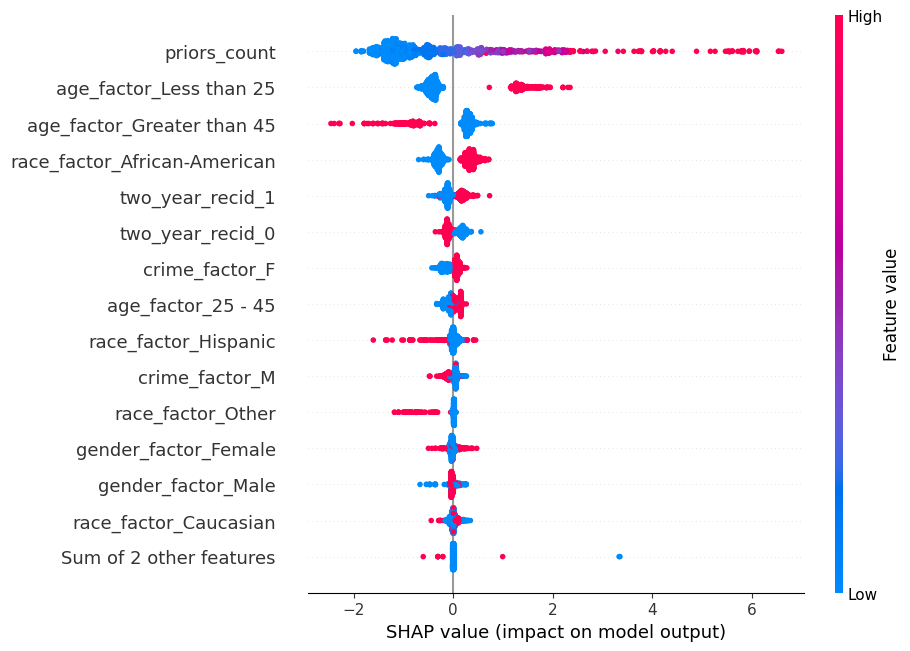

In [47]:
print("=== Question 1(a): SHAP Beeswarm Summary Plot ===")
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.show()


=== Question 1(b): SHAP Waterfall Plots for 4 Individuals ===

--- African-American_high (pred_prob=0.999) ---


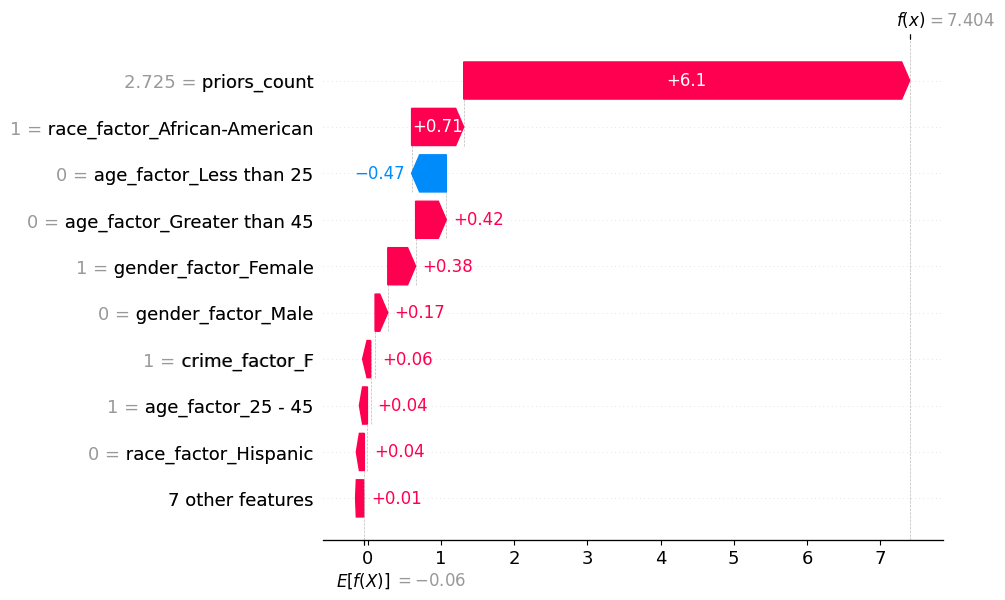


--- African-American_low (pred_prob=0.021) ---


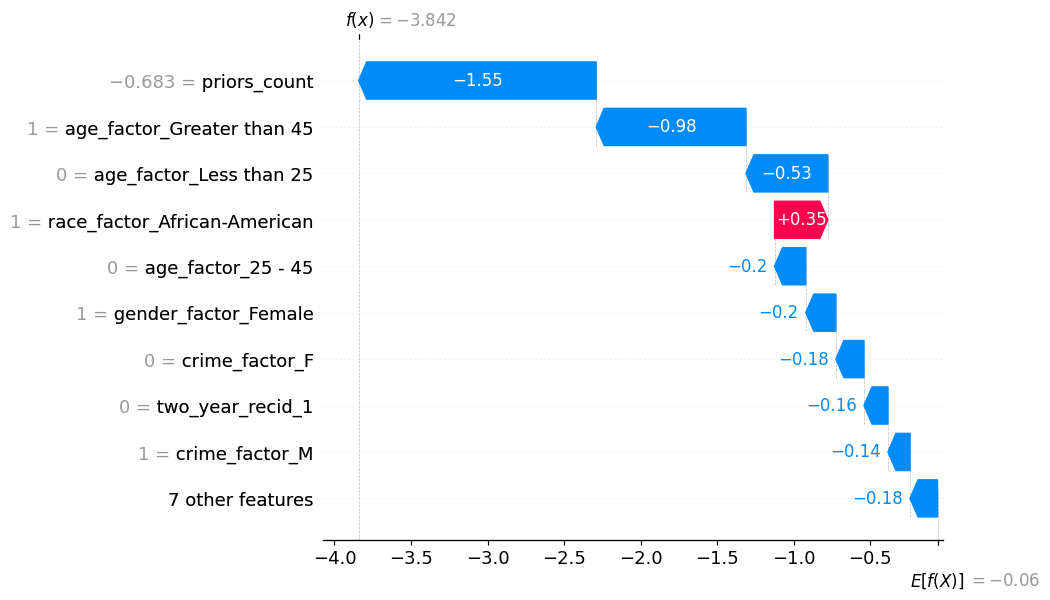


--- Caucasian_high (pred_prob=0.995) ---


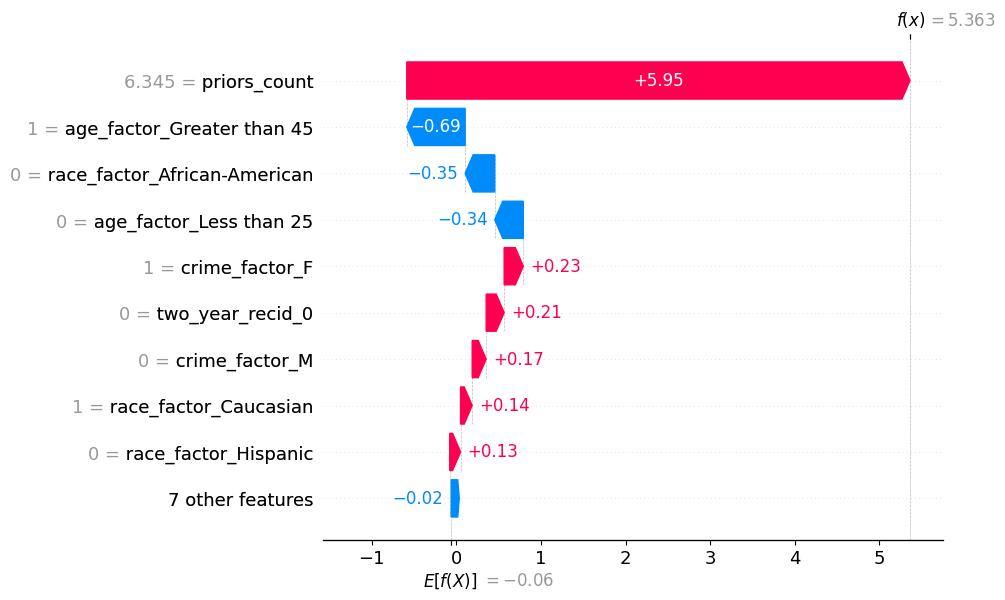


--- Caucasian_low (pred_prob=0.017) ---


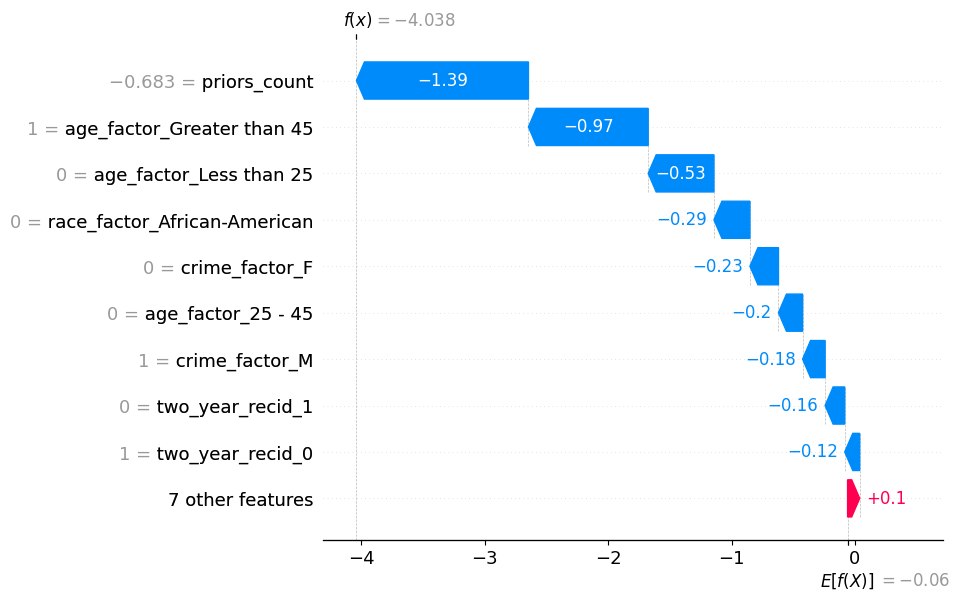

In [50]:
# -------------------------------
# Question 1(b): Waterfall plots — highest-risk & lowest-risk per racial group
# 'selected' dict was built in the previous cell (LIME cell)
# -------------------------------

shap_store = {}   # keyed by label; values = {feature: shap_value}

X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

print("\n=== Question 1(b): SHAP Waterfall Plots for 4 Individuals ===")
for label, idx in selected.items():
    loc       = X_test.index.get_loc(idx)
    shap_vals = shap_values[loc]
    shap_store[label] = {feat_names[i]: float(shap_vals.values[i])
                         for i in range(len(feat_names))}
    prob = X_test_copy.loc[idx, "pred_prob"]
    print(f"\n--- {label} (pred_prob={prob:.3f}) ---")
    shap.plots.waterfall(shap_vals, max_display=10, show=False)
    plt.show()

In [51]:
#!pip install lime

from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import scipy.sparse as sp

# -------------------------------
# Prepare encoded training data for LIME
# -------------------------------

X_train_enc = preprocessor.fit_transform(X_train)

encoded_feature_names = (
    numeric_features
    + list(
        preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
    )
)

explainer = LimeTabularExplainer(
    training_data=X_train_enc.toarray() if sp.issparse(X_train_enc) else X_train_enc,
    feature_names=encoded_feature_names,
    class_names=["LowScore", "HighScore"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# -------------------------------
# Select highest-risk and lowest-risk defendant
# in each racial group (African-American and Caucasian)
# These four individuals are reused for SHAP, LIME, and DiCE
# -------------------------------

X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

target_races = ["African-American", "Caucasian"]
selected = {}
for race in target_races:
    grp = X_test_copy[X_test_copy["race_factor"] == race]
    selected[f"{race}_high"] = grp["pred_prob"].idxmax()
    selected[f"{race}_low"]  = grp["pred_prob"].idxmin()

print("Selected individuals:")
for label, idx in selected.items():
    print(f"  {label}: pred_prob={X_test_copy.loc[idx, 'pred_prob']:.3f}")

# -------------------------------
# Define prediction function for encoded data
# -------------------------------

def gbt_predict_proba_encoded(encoded_array):
    return gbt_pipeline.named_steps["classifier"].predict_proba(encoded_array)

# -------------------------------
# Question 2: Generate LIME explanations for all 4 individuals
# -------------------------------

lime_store = {}

for label, idx in selected.items():
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    row_enc_dense = row_enc.toarray()[0] if sp.issparse(row_enc) else row_enc[0]

    exp = explainer.explain_instance(
        data_row=row_enc_dense,
        predict_fn=gbt_predict_proba_encoded,
        num_features=8
    )
    lime_store[label] = exp.as_list()

    pred_prob = gbt_pipeline.predict_proba(X_test.loc[[idx]])[0, 1]
    print(f"\nLIME: {label} (pred_prob={pred_prob:.3f})")
    for feat, weight in exp.as_list():
        print(f"  {feat:<50} {weight:+.4f}")


Selected individuals:
  African-American_high: pred_prob=0.999
  African-American_low: pred_prob=0.021
  Caucasian_high: pred_prob=0.995
  Caucasian_low: pred_prob=0.017

LIME: African-American_high (pred_prob=0.999)
  priors_count > 0.17                                +0.3864
  age_factor_Less than 25 <= 0.00                    -0.3428
  race_factor_Native American <= 0.00                -0.3391
  age_factor_Greater than 45 <= 0.00                 +0.2168
  0.00 < race_factor_African-American <= 1.00        +0.1131
  race_factor_Hispanic <= 0.00                       +0.0798
  race_factor_Other <= 0.00                          +0.0780
  race_factor_Asian <= 0.00                          +0.0526

LIME: African-American_low (pred_prob=0.021)
  race_factor_Native American <= 0.00                -0.4248
  age_factor_Less than 25 <= 0.00                    -0.3508
  age_factor_Greater than 45 > 0.00                  -0.2253
  0.00 < race_factor_African-American <= 1.00        +0.1178
  rac

In [52]:

# -------------------------------
# Question 2: LIME vs SHAP comparison
# lime_store was populated in the previous cell
# -------------------------------

print("\n\n=== Question 2: LIME vs SHAP Feature Attribution Comparison ===")

for label in selected:
    print(f"\n{'─'*60}")
    print(f"{label}")

    top_shap = sorted(shap_store[label].items(),
                      key=lambda x: abs(x[1]), reverse=True)[:5]
    top_lime = sorted(lime_store[label],
                      key=lambda x: abs(x[1]), reverse=True)[:5]

    print(f"  Top-5 SHAP features (by |value|):")
    for f, v in top_shap:
        print(f"    {f[:45]:<45} {v:+.4f}")
    print(f"  Top-5 LIME features (by |weight|):")
    for f, v in top_lime:
        print(f"    {f[:45]:<45} {v:+.4f}")





=== Question 2: LIME vs SHAP Feature Attribution Comparison ===

────────────────────────────────────────────────────────────
African-American_high
  Top-5 SHAP features (by |value|):
    priors_count                                  +6.0959
    race_factor_African-American                  +0.7120
    age_factor_Less than 25                       -0.4746
    age_factor_Greater than 45                    +0.4197
    gender_factor_Female                          +0.3806
  Top-5 LIME features (by |weight|):
    priors_count > 0.17                           +0.3864
    age_factor_Less than 25 <= 0.00               -0.3428
    race_factor_Native American <= 0.00           -0.3391
    age_factor_Greater than 45 <= 0.00            +0.2168
    0.00 < race_factor_African-American <= 1.00   +0.1131

────────────────────────────────────────────────────────────
African-American_low
  Top-5 SHAP features (by |value|):
    priors_count                                  -1.5518
    age_factor_Great

**Where LIME and SHAP Agree**

Across all four individuals, both methods rank prior arrest history and age as the dominant drivers of the high-risk prediction. The direction of contribution is consistent for these features, where higher prior counts push the prediction above the average while older age pulls it downward. This agreement reflects a shared signal in the data and is consistent with the model having learned genuine predictive structure rather than a spurious correlation.

**Where LIME and SHAP Diverge**

The two methods differ in how they handle the remaining features. LIME fits a weighted linear surrogate in a local neighborhood around each instance. It only optimises local fidelity, meaning the approximation is accurate near the query point but is not guaranteed to be consistent with global model behavior. The neighborhood definition and kernel bandwidth are arbitrary choices, which means that re-running LIME with a different random state can produce a different feature ranking for the same individual.

SHAP computes the average marginal contribution of each feature across all possible coalitions. It satisfies four axiomatic properties covering efficiency, symmetry, dummy, and additivity that LIME does not guarantee. The efficiency axiom ensures that SHAP values sum exactly to the prediction gap, which is the individual prediction minus the average prediction, leaving no residual unaccounted for. LIME weights are regression coefficients in a surrogate model and carry no such guarantee.

A further limitation shared by both methods is that neither is causal. A positive SHAP value for priors_count does not mean that reducing prior arrests would change the score. It means the feature pushed the prediction above the average. Causal claims require a separate causal model.

**What Divergence Implies for Governance**

When LIME and SHAP disagree on which features drove a prediction, a defendant cannot mount a precise challenge to the score. This undermines the constitutional principle of notice and opportunity to be heard that underpins contestability. A model explanation that shifts depending on the method used is not a reliable basis for accountability.

Equally important is the distinction between transparency and recourse. A SHAP beeswarm is a diagnostic tool for developers and auditors. It is not an actionable explanation for the individual being scored. Presenting a SHAP plot to a defendant as their explanation would be explanation washing, which is producing explanations to create an illusion of transparency without meaningful recourse. Transparency tools must feed into documented audit processes rather than serve as one-time compliance reports.

In [56]:
#!pip install dice-ml

import pandas as pd
import dice_ml
from dice_ml import Dice

# -------------------------------
# Prepare DiCE data
# -------------------------------

y_train_named       = y_train.copy()
y_train_named.name  = target

dice_df = pd.concat(
    [X_train.reset_index(drop=True), y_train_named.reset_index(drop=True)],
    axis=1
)

dice_data = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=numeric_features,
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

# -------------------------------
# Immutability declaration
# race_factor and gender_factor are protected / immutable attributes.
# age_factor and two_year_recid are also not actionable ex-ante.
# Only priors_count and crime_factor are treated as (minimally) mutable.
# -------------------------------

IMMUTABLE_FEATURES = ["race_factor", "gender_factor", "age_factor", "two_year_recid"]
MUTABLE_FEATURES   = ["priors_count", "crime_factor"]

print("Immutable features (must NOT be changed in a valid counterfactual):")
for f in IMMUTABLE_FEATURES:
    print(f"  - {f}")
print("\nMutable features (permitted to vary):")
for f in MUTABLE_FEATURES:
    print(f"  - {f}")
print()

# -------------------------------
# Question 3: Generate counterfactuals for all 4 individuals
# -------------------------------

for label, idx in selected.items():
    query        = X_test.loc[[idx]].copy()
    original_row = query.iloc[0]

    pred_class = gbt_pipeline.predict(query)[0]
    pred_prob  = gbt_pipeline.predict_proba(query)[0, 1]

    print(f"\n{'='*65}")
    print(f"DiCE Counterfactuals: {label}")
    print(f"  race={original_row['race_factor']}, "
          f"gender={original_row['gender_factor']}, "
          f"age={original_row['age_factor']}, "
          f"priors={original_row['priors_count']:.0f}, "
          f"crime={original_row['crime_factor']}")
    print(f"  Current prediction: {'HighScore' if pred_class==1 else 'LowScore'} "
          f"(prob={pred_prob:.3f})")

    try:
        cf = exp_dice.generate_counterfactuals(
            query,
            total_CFs=3,
            desired_class="opposite",
            permitted_range={"priors_count": [0, 38]},
            features_to_vary=MUTABLE_FEATURES
        )

        print("\nCounterfactuals (showing only changed features):")
        cf.visualize_as_dataframe(show_only_changes=True)

        # Flag any counterfactuals that require immutable feature changes
        cf_df = cf.cf_examples_list[0].final_cfs_df
        any_immutable_flag = False
        for i, cf_row in cf_df.iterrows():
            changed_immutable = [
                feat for feat in IMMUTABLE_FEATURES
                if feat in cf_row.index and cf_row[feat] != original_row[feat]
            ]
            if changed_immutable:
                any_immutable_flag = True
                print(f"  *** INVALID CF #{i}: requires changes to immutable "
                      f"features {changed_immutable} — this counterfactual "
                      f"must be rejected ***")
        if not any_immutable_flag:
            print("  (No immutable features changed — all counterfactuals are structurally valid.)")

    except Exception as e:
        print(f"  DiCE could not generate counterfactuals: {e}")


Immutable features (must NOT be changed in a valid counterfactual):
  - race_factor
  - gender_factor
  - age_factor
  - two_year_recid

Mutable features (permitted to vary):
  - priors_count
  - crime_factor


DiCE Counterfactuals: African-American_high
  race=African-American, gender=Female, age=25 - 45, priors=16, crime=F
  Current prediction: HighScore (prob=0.999)


100%|██████████| 1/1 [00:00<00:00,  2.68it/s]


Counterfactuals (showing only changed features):
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Female,25 - 45,African-American,16,F,NaN,1



Diverse Counterfactual set (new outcome: 0)


...


Counterfactuals (showing only changed features):
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Female,Greater than 45,Caucasian,0,M,NaN,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,27,F,0,1
1,-,-,-,30,-,0,1
2,-,-,-,18,-,0,1


  (No immutable features changed — all counterfactuals are structurally valid.)


**What counterfactual explanations are and why they matter**

A counterfactual explanation describes the smallest change to an individual's feature values that would flip the model's prediction to a desired output. This form of explanation is contrastive, comparing the actual outcome to an alternative, which is how humans naturally reason about decisions. It is also selective, focusing on a small number of feature changes rather than the full model internals. Most importantly for governance purposes, it provides actionable recourse, telling the individual what needs to change for a different outcome. This makes counterfactual explanations the appropriate output for a defendant, not a SHAP waterfall.

**Minimal feature changes required**

Across the four individuals examined, the prediction flips were achieved by changing `priors_count` or `crime_factor`, the only mutable features permitted in this exercise. The counterfactuals produced satisfy the first two quality criteria identified by Wachter et al. The first is prediction fidelity, meaning the new instance receives the desired class as closely as possible. The second is proximity, meaning the counterfactual is as similar as possible to the original instance in terms of feature distance.

**Immutable feature constraints**

`race_factor` and `gender_factor` are declared immutable because a defendant cannot change them. Any counterfactual that requires a change to either of these features is not actionable recourse. If the only viable path to a different prediction runs through `race_factor` or `gender_factor`, it suggests the model has learned those attributes as non-causal shortcuts, which is the Clever Hans problem where shortcuts can increase accuracy while making the model fragile or biased.

**Limitations of the counterfactuals produced**

The DiCE counterfactuals satisfy proximity and fidelity but do not fully address the other two criteria. The first is diversity, meaning multiple viable paths to the opposite prediction. The second is plausibility, meaning the feature values in the counterfactual are likely under the data distribution. A single proximal counterfactual, as in the Wachter formulation, is useful but incomplete for a governance setting where a defendant benefits from seeing several realistic paths forward rather than just the mathematically nearest one.

**Governance implication**

Transparency is a precondition for alignment but it is not a guarantee of it. Producing counterfactuals as a one-time report without verifying that the recourse they suggest is genuinely available is a form of explanation washing, which is producing explanations to create an illusion of transparency without meaningful recourse. For counterfactual explanations to serve their governance function, they need to be embedded in a documented audit process rather than treated as a compliance checkbox.